In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn import datasets


/home/admin123/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
dataset = datasets.load_digits()

In [4]:
dataset

{'data': array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ..., 10.,  0.,  0.],
        [ 0.,  0.,  0., ..., 16.,  9.,  0.],
        ...,
        [ 0.,  0.,  1., ...,  6.,  0.,  0.],
        [ 0.,  0.,  2., ..., 12.,  0.,  0.],
        [ 0.,  0., 10., ..., 12.,  1.,  0.]]),
 'target': array([0, 1, 2, ..., 8, 9, 8]),
 'frame': None,
 'feature_names': ['pixel_0_0',
  'pixel_0_1',
  'pixel_0_2',
  'pixel_0_3',
  'pixel_0_4',
  'pixel_0_5',
  'pixel_0_6',
  'pixel_0_7',
  'pixel_1_0',
  'pixel_1_1',
  'pixel_1_2',
  'pixel_1_3',
  'pixel_1_4',
  'pixel_1_5',
  'pixel_1_6',
  'pixel_1_7',
  'pixel_2_0',
  'pixel_2_1',
  'pixel_2_2',
  'pixel_2_3',
  'pixel_2_4',
  'pixel_2_5',
  'pixel_2_6',
  'pixel_2_7',
  'pixel_3_0',
  'pixel_3_1',
  'pixel_3_2',
  'pixel_3_3',
  'pixel_3_4',
  'pixel_3_5',
  'pixel_3_6',
  'pixel_3_7',
  'pixel_4_0',
  'pixel_4_1',
  'pixel_4_2',
  'pixel_4_3',
  'pixel_4_4',
  'pixel_4_5',
  'pixel_4_6',
  'pixel_4_7',
  'pixel_5_0',
  'pixel_5_1',
 

In [6]:
dataset.images.shape

(1797, 8, 8)

In [7]:
dataset.images[0]

array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
       [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
       [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
       [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
       [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
       [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
       [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
       [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]])

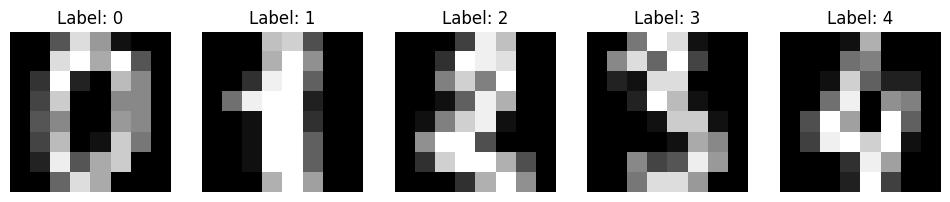

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for ax, image, label in zip(axes, dataset.images, dataset.target):
    ax.axis('off')
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Label: {label}')

plt.show()

In [11]:
n_samples = len(dataset.images)

In [13]:
data = dataset.images.reshape((n_samples, -1))

In [14]:
data.shape

(1797, 64)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, dataset.target, test_size=0.2, random_state=42)

In [18]:
from sklearn import svm, metrics

In [19]:
model = svm.SVC(gamma=0.001)

In [20]:
model.fit(X_train, y_train)

SVC(gamma=0.001)

In [21]:
predicted = model.predict(X_test)

In [26]:
predicted[5:10]

array([1, 5, 2, 5, 2])

In [27]:
y_test[5:10]

array([1, 5, 2, 5, 2])

In [29]:
correct = 0
total = len(y_test)
for i in range(total):
    if predicted[i] == y_test[i]:
        correct += 1
    else:
        print(f'i={i}, predicted={predicted[i]}, actual={y_test[i]}')

accuracy = correct / total

print(f'Accuracy: {accuracy:.2%}')

i=133, predicted=9, actual=7
i=149, predicted=5, actual=3
i=159, predicted=7, actual=9
i=339, predicted=6, actual=5
Accuracy: 98.89%
